# PINN 求解 curl curl u + u = f 
## 问题描述

在 2D L-shape 域 $\Omega = [-1,1]^2 \setminus [0,1] \times [-1,0]$ 上：

$$\nabla \times \nabla \times \mathbf{u} + \mathbf{u} = \mathbf{f}, \quad \mathbf{u} \times \mathbf{n} = 0 \text{ on } \partial\Omega$$

以 `FEM_nedelec_curlcurl.ipynb` 生成的 Nédélec FEM 解为 Ground Truth，训练 PINN 并对比分析。

### 数据来源

- `fem_curlcurl_data.npz`: 内部/边界采样点 + FEM 解值 + f 值 (PINN 训练用)
- `fem_grid_data.npz`: 规则网格上的 FEM 解 (对比可视化用)



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 加载 FEM 采样数据 (由 FEM_nedelec_curlcurl.ipynb 生成)
data = np.load('fem_curlcurl_data.npz')
x_col = torch.tensor(data['x_int'], dtype=torch.float32).to(device)
u_fem = torch.tensor(data['u_int'], dtype=torch.float32).to(device)
f_rhs = torch.tensor(data['f_int'], dtype=torch.float32).to(device)
x_bc  = torch.tensor(data['x_bnd'], dtype=torch.float32).to(device)
u_bc_true = torch.tensor(data['u_bnd'], dtype=torch.float32).to(device)

print(f'Interior points: {x_col.shape}, Boundary points: {x_bc.shape}')


Using device: cuda
Interior points: torch.Size([10000, 2]), Boundary points: torch.Size([3000, 2])


In [2]:
# ===================== PINN 向量网络 =====================
class CubicReLU(nn.Module):
    def forward(self, x):
        return torch.pow(torch.relu(x), 3)

class VectorPINN(nn.Module):
    def __init__(self, activation_name='tanh', hidden_dim=128, n_layers=4):
        super().__init__()
        self.activation_name = activation_name
        if activation_name == 'tanh': act = nn.Tanh()
        elif activation_name == 'relu3': act = CubicReLU()
        elif activation_name == 'gelu': act = nn.GELU()
        else: act = nn.Tanh()
        
        layers = [nn.Linear(2, hidden_dim), act]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), act]
        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)
        
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)


In [3]:
# ===================== PDE 残差: curl curl u + u - f = 0 =====================
#
# 在 2D 中, u = (u₁, u₂):
#   curl u (标量) = ∂u₂/∂x - ∂u₁/∂y
#   curl curl u (向量) = (∂(curl u)/∂y, -∂(curl u)/∂x)
#
# 因此 PDE 残差:
#   res_x = ∂(curl u)/∂y + u₁ - f₁ = 0
#   res_y = -∂(curl u)/∂x + u₂ - f₂ = 0

def curlcurl_residual(model, x_in, f_rhs):
    x_in = x_in.detach().requires_grad_(True)
    u = model(x_in)
    u1, u2 = u[:, 0:1], u[:, 1:2]
    
    # 计算 grad u₁ 和 grad u₂
    grad_u1 = torch.autograd.grad(u1, x_in, torch.ones_like(u1), create_graph=True)[0]
    grad_u2 = torch.autograd.grad(u2, x_in, torch.ones_like(u2), create_graph=True)[0]
    du1_dy = grad_u1[:, 1:2]  # ∂u₁/∂y
    du2_dx = grad_u2[:, 0:1]  # ∂u₂/∂x
    
    # 标量 curl: curl u = ∂u₂/∂x - ∂u₁/∂y
    scalar_curl = du2_dx - du1_dy
    
    # curl curl u 需要对标量 curl 再取梯度
    grad_curl = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0]
    # grad_curl[:, 0] = ∂(curl u)/∂x
    # grad_curl[:, 1] = ∂(curl u)/∂y
    
    # curl curl u = (∂(curl u)/∂y, -∂(curl u)/∂x)
    # PDE: curl curl u + u = f
    res_x =  grad_curl[:, 1:2] + u1 - f_rhs[:, 0:1]   # ∂(curl u)/∂y + u₁ - f₁
    res_y = -grad_curl[:, 0:1] + u2 - f_rhs[:, 1:2]   # -∂(curl u)/∂x + u₂ - f₂
    return res_x, res_y


In [4]:
# ===================== Phase 1 训练 (Adam + StepLR) =====================
ACT_TYPE = 'tanh'
model = VectorPINN(ACT_TYPE, hidden_dim=128, n_layers=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

w_pde, w_bc, w_data = 1.0, 50.0, 1.0
loss_history = []

print(f'--- Training PINN ({ACT_TYPE}), params={sum(p.numel() for p in model.parameters())} ---')
for epoch in range(20001):
    optimizer.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)
    loss_bc = torch.mean((model(x_bc) - u_bc_true)**2)
    loss_data = torch.mean((model(x_col) - u_fem)**2)
    loss = w_pde*loss_pde + w_bc*loss_bc + w_data*loss_data
    loss.backward(); optimizer.step(); scheduler.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e}, Data={loss_data.item():.3e})')


--- Training PINN (tanh), params=50178 ---
Epoch     0: Loss=1.7062e+00 (PDE=1.047e+00, BC=1.291e-02, Data=1.334e-02)
Epoch     0: Loss=1.7062e+00 (PDE=1.047e+00, BC=1.291e-02, Data=1.334e-02)
Epoch  2000: Loss=9.5733e-03 (PDE=1.466e-03, BC=1.598e-04, Data=1.154e-04)
Epoch  4000: Loss=3.9333e-04 (PDE=3.208e-04, BC=1.386e-06, Data=3.262e-06)
Epoch  6000: Loss=2.3180e-04 (PDE=1.979e-04, BC=6.481e-07, Data=1.531e-06)
Epoch  8000: Loss=1.2020e-04 (PDE=1.031e-04, BC=3.279e-07, Data=7.007e-07)
Epoch 10000: Loss=8.6479e-05 (PDE=5.229e-05, BC=6.688e-07, Data=7.451e-07)
Epoch 12000: Loss=9.8076e-05 (PDE=3.423e-05, BC=1.251e-06, Data=1.295e-06)
Epoch 14000: Loss=3.2672e-04 (PDE=4.657e-05, BC=5.514e-06, Data=4.466e-06)
Epoch 16000: Loss=1.5766e-05 (PDE=1.329e-05, BC=4.537e-08, Data=2.122e-07)
Epoch 18000: Loss=1.8616e-05 (PDE=1.026e-05, BC=1.618e-07, Data=2.616e-07)
Epoch 20000: Loss=9.4513e-05 (PDE=1.835e-05, BC=1.480e-06, Data=2.154e-06)


In [5]:
# ===================== Phase 2 微调训练 =====================
optimizer2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=5000, gamma=0.5)

for epoch in range(20001, 40001):
    optimizer2.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)
    loss_bc = torch.mean((model(x_bc) - u_bc_true)**2)
    loss_data = torch.mean((model(x_col) - u_fem)**2)
    loss = w_pde*loss_pde + w_bc*loss_bc + w_data*loss_data
    loss.backward(); optimizer2.step(); scheduler2.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e}, Data={loss_data.item():.3e})')


Epoch 22000: Loss=1.7715e-05 (PDE=7.419e-06, BC=2.012e-07, Data=2.339e-07)
Epoch 24000: Loss=8.1706e-06 (PDE=5.754e-06, BC=4.558e-08, Data=1.378e-07)
Epoch 24000: Loss=8.1706e-06 (PDE=5.754e-06, BC=4.558e-08, Data=1.378e-07)
Epoch 26000: Loss=6.3741e-06 (PDE=5.047e-06, BC=2.422e-08, Data=1.156e-07)
Epoch 26000: Loss=6.3741e-06 (PDE=5.047e-06, BC=2.422e-08, Data=1.156e-07)
Epoch 28000: Loss=6.1151e-06 (PDE=4.498e-06, BC=3.013e-08, Data=1.099e-07)
Epoch 28000: Loss=6.1151e-06 (PDE=4.498e-06, BC=3.013e-08, Data=1.099e-07)
Epoch 30000: Loss=5.8014e-06 (PDE=4.083e-06, BC=3.229e-08, Data=1.038e-07)
Epoch 30000: Loss=5.8014e-06 (PDE=4.083e-06, BC=3.229e-08, Data=1.038e-07)
Epoch 32000: Loss=6.8352e-06 (PDE=3.935e-06, BC=5.541e-08, Data=1.292e-07)
Epoch 32000: Loss=6.8352e-06 (PDE=3.935e-06, BC=5.541e-08, Data=1.292e-07)
Epoch 34000: Loss=6.0480e-06 (PDE=3.511e-06, BC=4.866e-08, Data=1.039e-07)
Epoch 34000: Loss=6.0480e-06 (PDE=3.511e-06, BC=4.866e-08, Data=1.039e-07)
Epoch 36000: Loss=3.9956e

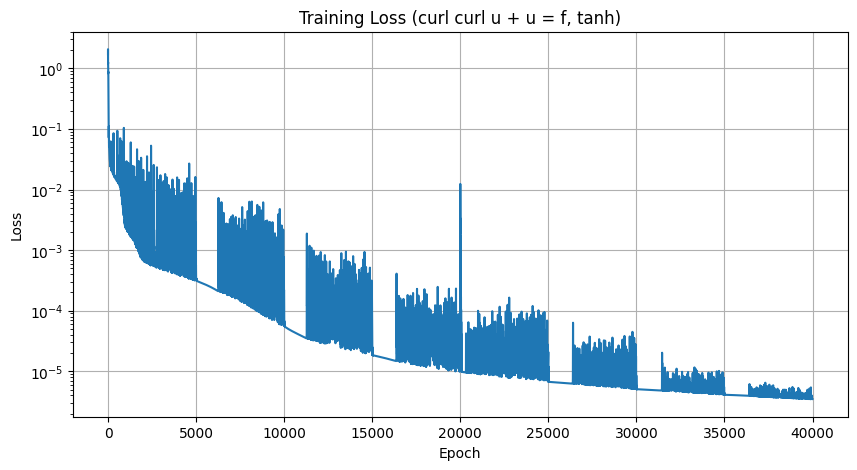

In [6]:
# ===================== Loss 曲线 =====================
plt.figure(figsize=(10, 5))
plt.semilogy(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Training Loss (curl curl u + u = f, {ACT_TYPE})')
plt.grid(True); plt.show()


In [7]:
# ===================== PINN 网格评估函数 =====================
def evaluate_on_grid(model, device, x_range, y_range, n_grid=120):
    """在规则网格上评估 PINN 模型, L-shape 缺失区域设为 NaN"""
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    XY_torch = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)
    mask = (X > 0) & (Y < 0)
    with torch.no_grad():
        U = model(XY_torch).cpu().numpy()
    ux = U[:,0].reshape(n_grid, n_grid)
    uy = U[:,1].reshape(n_grid, n_grid)
    umag = np.sqrt(ux**2 + uy**2)
    ux[mask] = np.nan; uy[mask] = np.nan; umag[mask] = np.nan
    return X, Y, ux, uy, umag, mask


Evaluating PINN on 100x100 grid...


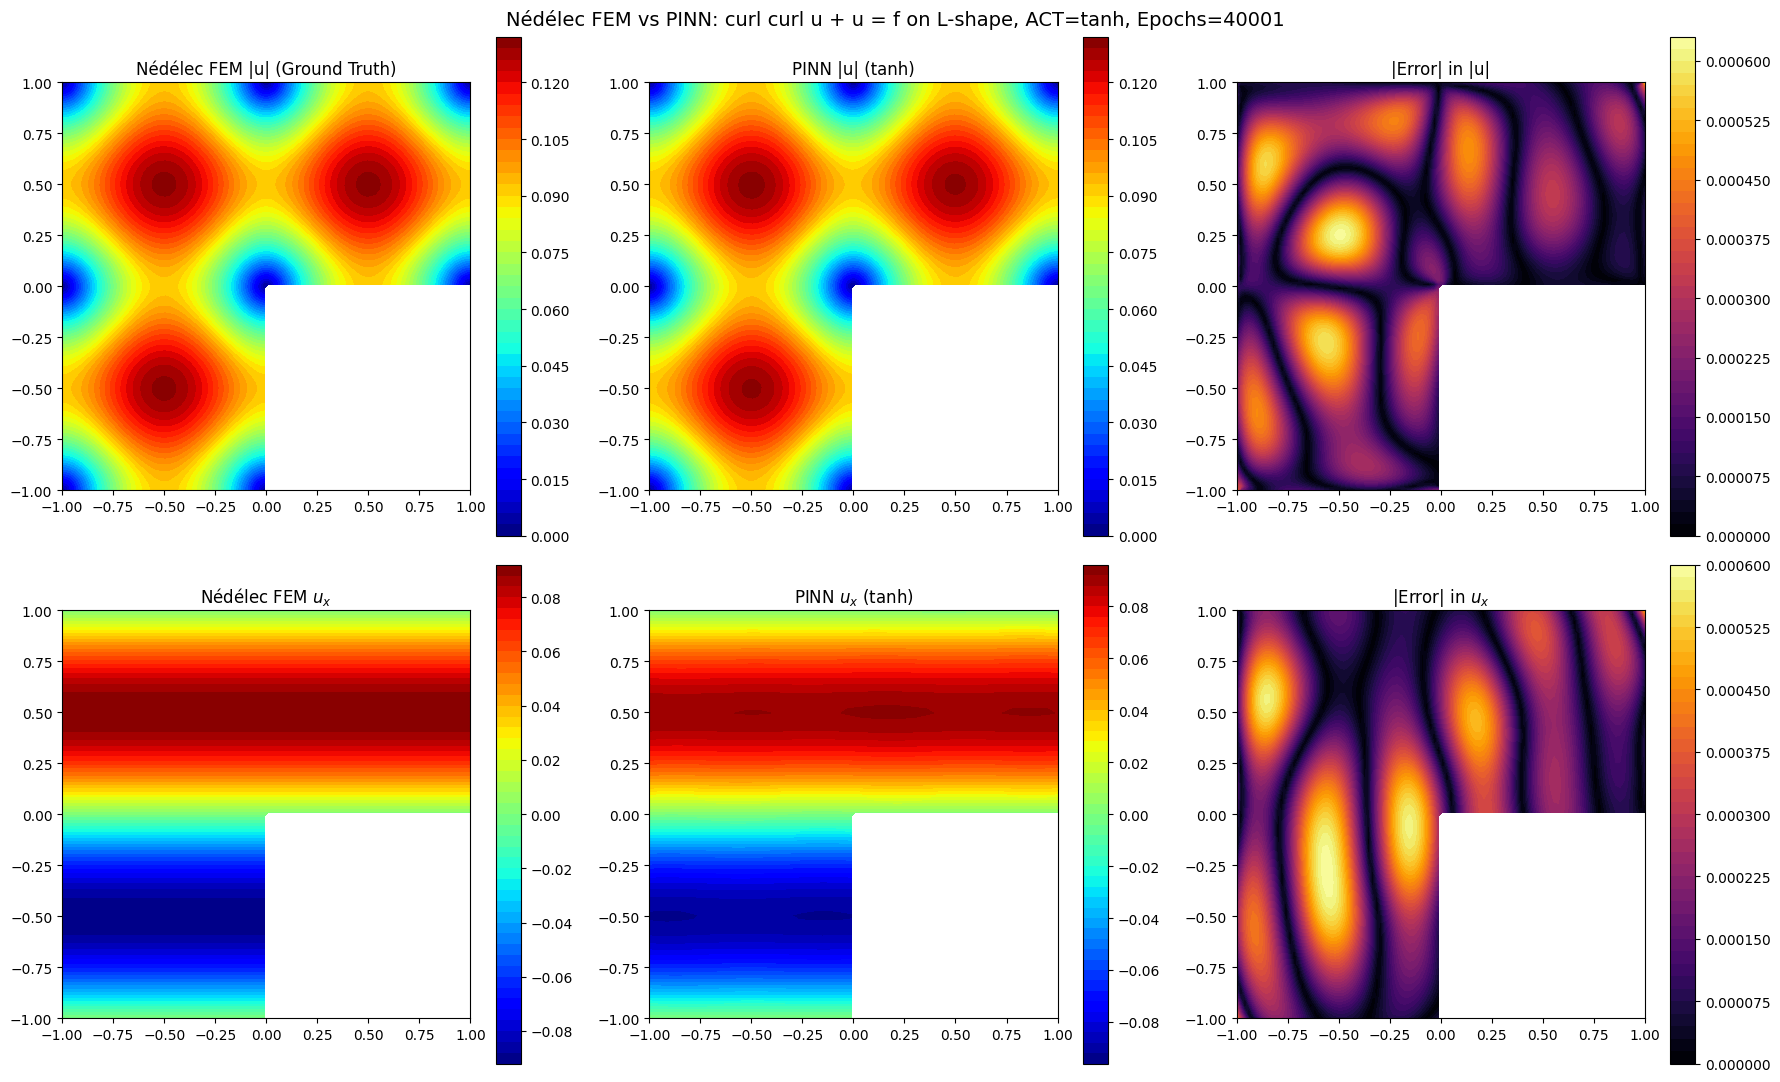


=== Error Statistics ===
  Max |u| error:  6.213087e-04
  Mean |u| error: 1.991879e-04
  L2 relative:    2.675690e-03


In [8]:
# ===================== 加载 FEM 网格数据并对比可视化 =====================
# 从 fem_grid_data.npz 加载预计算的 FEM 网格解 (无需 ngsolve!)
fem_grid = np.load('fem_grid_data.npz')
Xf, Yf = fem_grid['Xf'], fem_grid['Yf']
uxf, uyf, uf = fem_grid['uxf'], fem_grid['uyf'], fem_grid['uf']

# PINN 在同样网格上评估
ng = Xf.shape[0]
print(f'Evaluating PINN on {ng}x{ng} grid...')
Xp, Yp, uxp, uyp, up, mp = evaluate_on_grid(model, device, (-1, 1), (-1, 1), ng)

# --- FEM vs PINN 对比 (2×3 子图) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

im00 = axes[0,0].contourf(Xf, Yf, uf, levels=50, cmap='jet')
axes[0,0].set_title('Nédélec FEM |u| (Ground Truth)'); axes[0,0].set_aspect('equal'); fig.colorbar(im00, ax=axes[0,0])

im01 = axes[0,1].contourf(Xp, Yp, up, levels=50, cmap='jet')
axes[0,1].set_title(f'PINN |u| ({ACT_TYPE})'); axes[0,1].set_aspect('equal'); fig.colorbar(im01, ax=axes[0,1])

err_mag = np.abs(up - uf)
im02 = axes[0,2].contourf(Xf, Yf, err_mag, levels=50, cmap='inferno')
axes[0,2].set_title('|Error| in |u|'); axes[0,2].set_aspect('equal'); fig.colorbar(im02, ax=axes[0,2])

im10 = axes[1,0].contourf(Xf, Yf, uxf, levels=50, cmap='jet')
axes[1,0].set_title(r'Nédélec FEM $u_x$'); axes[1,0].set_aspect('equal'); fig.colorbar(im10, ax=axes[1,0])

im11 = axes[1,1].contourf(Xp, Yp, uxp, levels=50, cmap='jet')
axes[1,1].set_title(f'PINN $u_x$ ({ACT_TYPE})'); axes[1,1].set_aspect('equal'); fig.colorbar(im11, ax=axes[1,1])

err_ux = np.abs(uxp - uxf)
im12 = axes[1,2].contourf(Xf, Yf, err_ux, levels=50, cmap='inferno')
axes[1,2].set_title(r'|Error| in $u_x$'); axes[1,2].set_aspect('equal'); fig.colorbar(im12, ax=axes[1,2])

plt.suptitle(f'Nédélec FEM vs PINN: curl curl u + u = f on L-shape, ACT={ACT_TYPE}, Epochs={len(loss_history)}', fontsize=14)
plt.tight_layout(); plt.show()

print(f'\n=== Error Statistics ===')
print(f'  Max |u| error:  {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| error: {np.nanmean(err_mag):.6e}')
print(f'  L2 relative:    {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')


Evaluating PINN on zoom grid 100x100 near re-entrant corner...


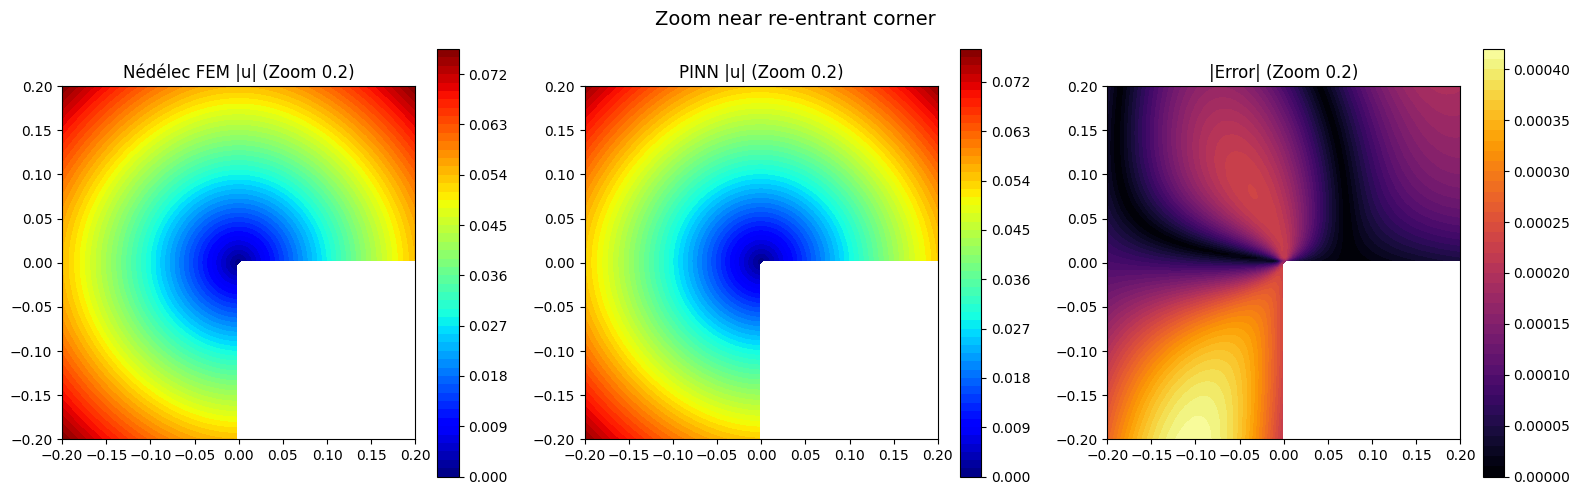

Zoom - Max err: 4.176973e-04, Mean err: 1.634209e-04


In [9]:
# ===================== Zoom-in 凹角附近误差分析 =====================
# 加载预计算的 FEM zoom 数据
Xfz, Yfz = fem_grid['Xfz'], fem_grid['Yfz']
ufz = fem_grid['ufz']

nz = Xfz.shape[0]
print(f'Evaluating PINN on zoom grid {nz}x{nz} near re-entrant corner...')
Xpz, Ypz, _, _, upz, _ = evaluate_on_grid(model, device, (-0.2, 0.2), (-0.2, 0.2), nz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xfz, Yfz, ufz, levels=50, cmap='jet')
axes[0].set_title('Nédélec FEM |u| (Zoom 0.2)'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xpz, Ypz, upz, levels=50, cmap='jet')
axes[1].set_title('PINN |u| (Zoom 0.2)'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_z = np.abs(upz - ufz)
im2 = axes[2].contourf(Xfz, Yfz, err_z, levels=50, cmap='inferno')
axes[2].set_title('|Error| (Zoom 0.2)'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle('Zoom near re-entrant corner', fontsize=14); plt.tight_layout(); plt.show()
print(f'Zoom - Max err: {np.nanmax(err_z):.6e}, Mean err: {np.nanmean(err_z):.6e}')


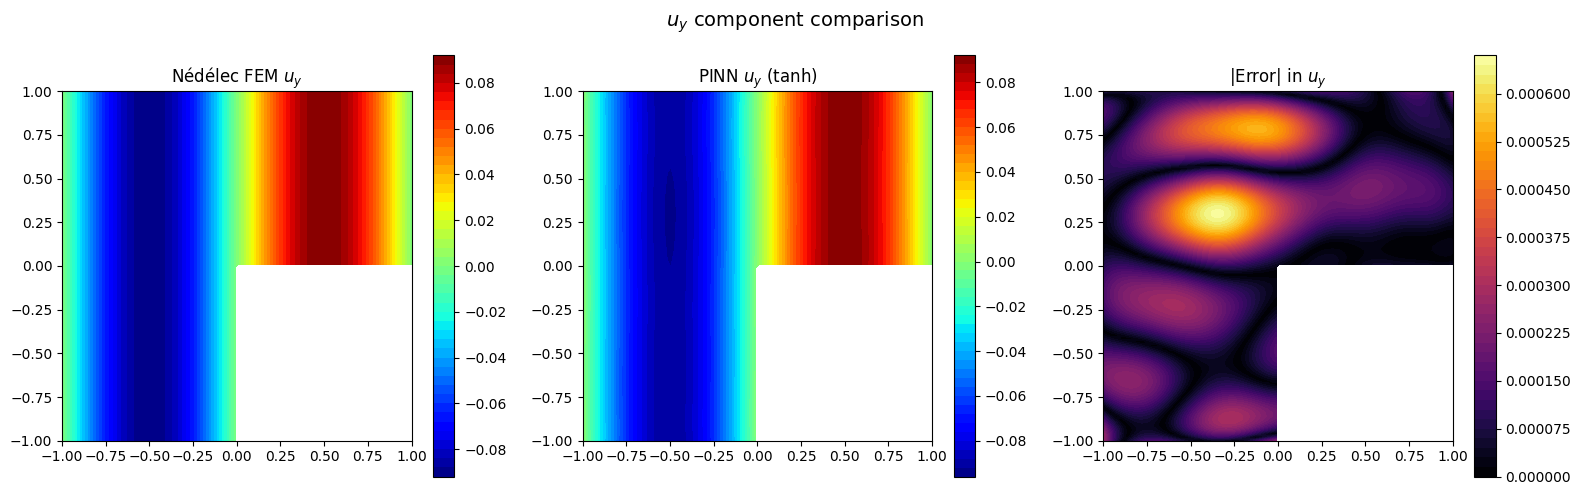

In [10]:
# ===================== u_y 分量对比可视化 =====================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xf, Yf, uyf, levels=50, cmap='jet')
axes[0].set_title(r'Nédélec FEM $u_y$'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xp, Yp, uyp, levels=50, cmap='jet')
axes[1].set_title(f'PINN $u_y$ ({ACT_TYPE})'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_uy = np.abs(uyp - uyf)
im2 = axes[2].contourf(Xf, Yf, err_uy, levels=50, cmap='inferno')
axes[2].set_title(r'|Error| in $u_y$'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle(r'$u_y$ component comparison', fontsize=14); plt.tight_layout(); plt.show()


In [11]:
# ===================== 保存模型与误差汇总 =====================
torch.save({'model_state_dict': model.state_dict(), 'activation': ACT_TYPE,
            'loss_history': loss_history, 'epochs': len(loss_history)}, 'pinn_curlcurl_model.pth')

print(f'\n{"="*55}')
print(f'  Final Results Summary')
print(f'{"="*55}')
print(f'  Equation:    curl curl u + u = f')
print(f'  Domain:      L-shape [-1,1]² \\ [0,1]×[-1,0]')
print(f'  FEM:         Nédélec edge elements (HCurl), order=2')
print(f'  BC:          u × n = 0 (tangential homogeneous)')
print(f'  f:           (sin(πy), sin(πx))')
print(f'  Activation:  {ACT_TYPE}')
print(f'  Total epochs:{len(loss_history)}')
print(f'  Final loss:  {loss_history[-1]:.6e}')
print(f'  Max |u| err: {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| err:{np.nanmean(err_mag):.6e}')
print(f'  L2 relative: {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')



  Final Results Summary
  Equation:    curl curl u + u = f
  Domain:      L-shape [-1,1]² \ [0,1]×[-1,0]
  FEM:         Nédélec edge elements (HCurl), order=2
  BC:          u × n = 0 (tangential homogeneous)
  f:           (sin(πy), sin(πx))
  Activation:  tanh
  Total epochs:40001
  Final loss:  3.491115e-06
  Max |u| err: 6.213087e-04
  Mean |u| err:1.991879e-04
  L2 relative: 2.675690e-03
